In [2]:
# ── Install dependencies ──────────────────────────────────────────────────
!pip install scikit-surprise
import warnings, os, time, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.sparse import csr_matrix
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder

from surprise import (
    Dataset, Reader, SVD,
    KNNWithMeans, BaselineOnly, accuracy
)
from surprise.model_selection import (
    cross_validate, GridSearchCV,
    train_test_split as surprise_split
)

# ── Plot aesthetics ────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#FF9900', '#232F3E', '#146EB4', '#FF6B35', '#00A8CC', '#7B2D8B']
sns.set_palette(PALETTE)
np.random.seed(42)

print("✅ Environment ready")
print(f"   NumPy {np.__version__} | Pandas {pd.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.9 MB/s eta 0:00:00
✅ Environment ready
   NumPy 2.0.2 | Pandas 2.2.2


In [3]:
# ── Load MovieLens 100K via Surprise (auto-downloads ~5 MB) ──────────────
print("Loading MovieLens 100K dataset...")
t0 = time.time()
data = Dataset.load_builtin('ml-100k', prompt=False)

# Load as DataFrame for EDA and visualization
ratings_df = pd.read_csv(
    os.path.expanduser('~/.surprise_data/ml-100k/ml-100k/u.data'),
    sep='\t',
    names=['userId', 'movieId', 'rating', 'timestamp']
)

# Load movie metadata (title + genre one-hot)
movies_df = pd.read_csv(
    os.path.expanduser('~/.surprise_data/ml-100k/ml-100k/u.item'),
    sep='|', encoding='latin-1', header=None,
    names=['movieId','title','release_date','video_release','imdb_url',
           'unknown','Action','Adventure','Animation',"Children's",'Comedy',
           'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
           'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western']
)
GENRE_COLS = ['Action','Adventure','Animation',"Children's",'Comedy','Crime',
              'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical',
              'Mystery','Romance','Sci-Fi','Thriller','War','Western']
movies_df = movies_df[['movieId','title','release_date'] + GENRE_COLS]

N_USERS   = ratings_df.userId.nunique()
N_MOVIES  = ratings_df.movieId.nunique()
N_RATINGS = len(ratings_df)
SPARSITY  = 1 - N_RATINGS / (N_USERS * N_MOVIES)

print(f"✅ Dataset loaded in {time.time()-t0:.1f}s")
print(f"\nDataset Statistics")
print(f"{'─'*35}")
print(f"  Ratings  : {N_RATINGS:>8,}")
print(f"  Users    : {N_USERS:>8,}")
print(f"  Movies   : {N_MOVIES:>8,}")
print(f"  Sparsity : {SPARSITY:>8.2%}")
print(f"  Density  : {1-SPARSITY:>8.2%}")
ratings_df.head()

Loading MovieLens 100K dataset...
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k
✅ Dataset loaded in 1.4s

Dataset Statistics
───────────────────────────────────
  Ratings  :  100,000
  Users    :      943
  Movies   :    1,682
  Sparsity :   93.70%
  Density  :    6.30%


,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


User activity   — median: 65, mean: 106.0, max: 737
Item popularity — median: 27, mean: 59.5, max: 583


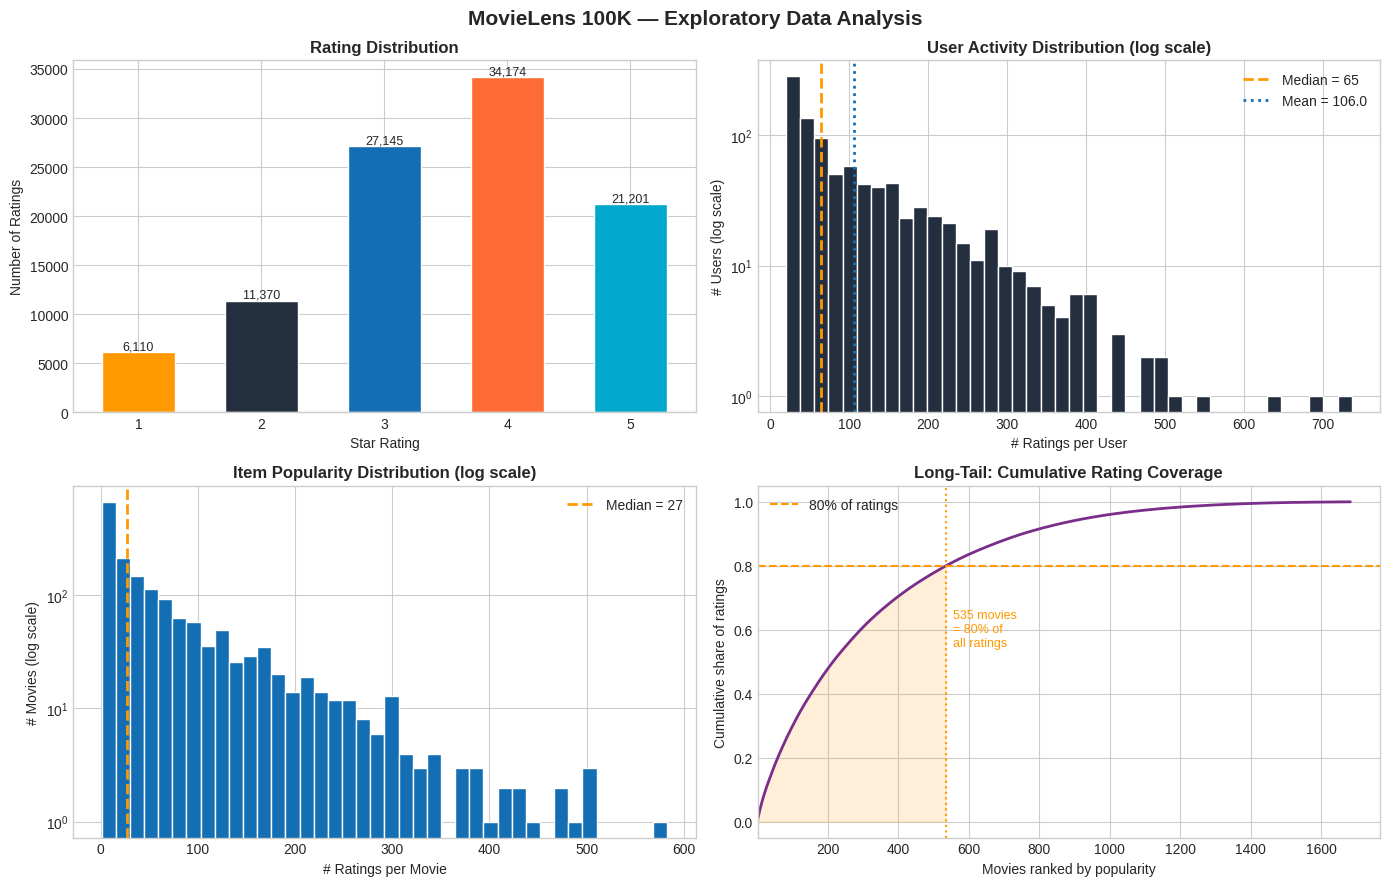


📊 Key Insights:
   • 93.70% sparse — matrix factorization needed for scalability
   • Top 535 movies (31.8%) account for 80% of all ratings — long-tail confirmed
   • 0 users (0.0%) have < 5 ratings — cold-start risk


In [4]:
# ── Compute distributions ─────────────────────────────────────────────────
user_activity   = ratings_df.groupby('userId')['movieId'].count()
item_popularity = ratings_df.groupby('movieId')['userId'].count()

print(f"User activity   — median: {user_activity.median():.0f}, "
      f"mean: {user_activity.mean():.1f}, max: {user_activity.max()}")
print(f"Item popularity — median: {item_popularity.median():.0f}, "
      f"mean: {item_popularity.mean():.1f}, max: {item_popularity.max()}")

# ── 4-panel EDA figure ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('MovieLens 100K — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# 1. Rating distribution
ax = axes[0, 0]
rating_counts = ratings_df['rating'].value_counts().sort_index()
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=PALETTE[:5], edgecolor='white', width=0.6)
ax.set_title('Rating Distribution', fontweight='bold')
ax.set_xlabel('Star Rating'); ax.set_ylabel('Number of Ratings')
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 300,
            f'{val:,}', ha='center', fontsize=9)
ax.set_xticks([1, 2, 3, 4, 5])

# 2. User activity distribution (log scale)
ax = axes[0, 1]
ax.hist(user_activity, bins=40, color=PALETTE[1], edgecolor='white', log=True)
ax.axvline(user_activity.median(), color=PALETTE[0], linestyle='--', linewidth=2,
           label=f'Median = {user_activity.median():.0f}')
ax.axvline(user_activity.mean(), color=PALETTE[2], linestyle=':', linewidth=2,
           label=f'Mean = {user_activity.mean():.1f}')
ax.set_title('User Activity Distribution (log scale)', fontweight='bold')
ax.set_xlabel('# Ratings per User'); ax.set_ylabel('# Users (log scale)')
ax.legend()

# 3. Item popularity distribution (log scale)
ax = axes[1, 0]
ax.hist(item_popularity, bins=40, color=PALETTE[2], edgecolor='white', log=True)
ax.axvline(item_popularity.median(), color=PALETTE[0], linestyle='--', linewidth=2,
           label=f'Median = {item_popularity.median():.0f}')
ax.set_title('Item Popularity Distribution (log scale)', fontweight='bold')
ax.set_xlabel('# Ratings per Movie'); ax.set_ylabel('# Movies (log scale)')
ax.legend()

# 4. Long-tail cumulative coverage
ax = axes[1, 1]
sorted_pop = item_popularity.sort_values(ascending=False)
cumulative  = sorted_pop.cumsum() / sorted_pop.sum()
ax.plot(range(1, len(cumulative)+1), cumulative.values, color=PALETTE[5], linewidth=2)
ax.axhline(0.8, color=PALETTE[0], linestyle='--', linewidth=1.5, label='80% of ratings')
n80 = int((cumulative <= 0.8).sum())
ax.axvline(n80, color=PALETTE[0], linestyle=':', linewidth=1.5)
ax.fill_between(range(1, n80+1), cumulative.values[:n80], alpha=0.15, color=PALETTE[0])
ax.set_title('Long-Tail: Cumulative Rating Coverage', fontweight='bold')
ax.set_xlabel('Movies ranked by popularity'); ax.set_ylabel('Cumulative share of ratings')
ax.legend(); ax.set_xlim(1)
ax.text(n80+20, 0.55, f'{n80} movies\n= 80% of\nall ratings', fontsize=9, color=PALETTE[0])

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Key Insights:")
print(f"   • {SPARSITY:.2%} sparse — matrix factorization needed for scalability")
print(f"   • Top {n80} movies ({n80/N_MOVIES:.1%}) account for 80% of all ratings — long-tail confirmed")
cold_users = (user_activity < 5).sum()
print(f"   • {cold_users} users ({cold_users/N_USERS:.1%}) have < 5 ratings — cold-start risk")

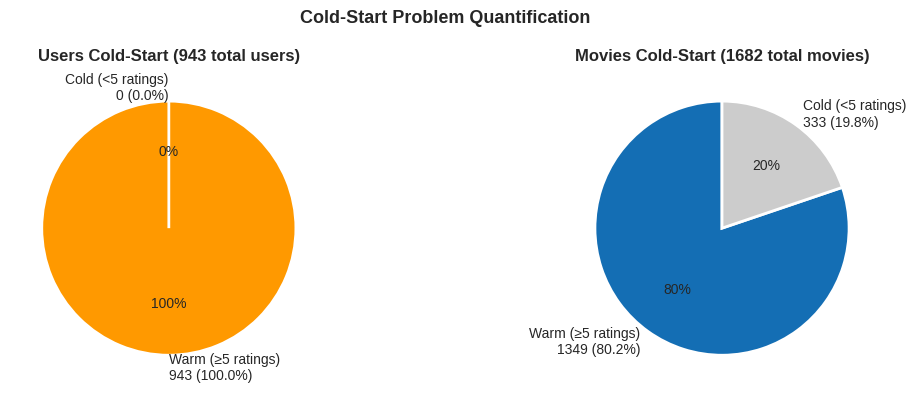

Cold-Start Summary (threshold = 5 ratings):
  Users  :    0 cold (0.0%)  →  popularity fallback
  Movies :  333 cold (19.8%) →  excluded from CF / genre similarity


In [5]:
# ── Cold-start quantification ─────────────────────────────────────────────
COLD_THRESHOLD = 5

cold_users  = (user_activity  < COLD_THRESHOLD).sum()
warm_users  = (user_activity  >= COLD_THRESHOLD).sum()
cold_movies = (item_popularity < COLD_THRESHOLD).sum()
warm_movies = (item_popularity >= COLD_THRESHOLD).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Cold-Start Problem Quantification', fontsize=13, fontweight='bold')

for ax, warm, cold, total, label, color in [
    (axes[0], warm_users,  cold_users,  N_USERS,  'Users',  PALETTE[0]),
    (axes[1], warm_movies, cold_movies, N_MOVIES, 'Movies', PALETTE[2])
]:
    ax.pie(
        [warm, cold],
        labels=[f'Warm (≥{COLD_THRESHOLD} ratings)\n{warm} ({warm/total:.1%})',
                f'Cold (<{COLD_THRESHOLD} ratings)\n{cold} ({cold/total:.1%})'],
        colors=[color, '#CCCCCC'],
        autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2),
        textprops=dict(fontsize=10)
    )
    ax.set_title(f'{label} Cold-Start ({total} total {label.lower()})', fontweight='bold')

plt.tight_layout()
plt.savefig('cold_start_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Cold-Start Summary (threshold = {COLD_THRESHOLD} ratings):")
print(f"  Users  : {cold_users:>4} cold ({cold_users/N_USERS:.1%})  →  popularity fallback")
print(f"  Movies : {cold_movies:>4} cold ({cold_movies/N_MOVIES:.1%}) →  excluded from CF / genre similarity")

User-Item Matrix:
  Shape           : (943, 1682)
  Non-zero cells  : 100,000
  Sparse memory   : 0.80 MB
  Dense equivalent: 12.7 MB
  Compression     : 16× smaller (sparse vs dense)


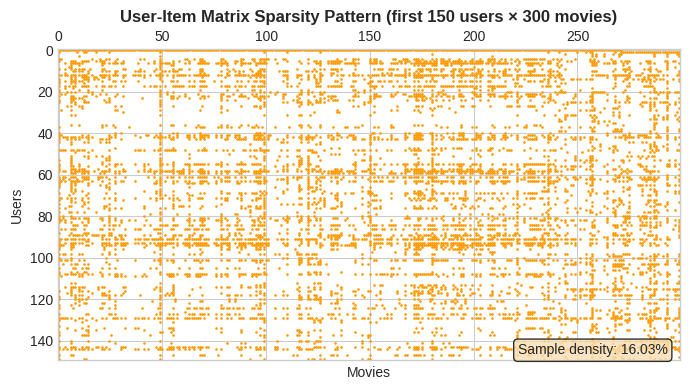


Train/Test Split (80/20, random_state=42):
  Training ratings : 80,000
  Test ratings     : 20,000


In [6]:
# ── Build sparse user-item matrix ─────────────────────────────────────────
user_enc  = LabelEncoder()
movie_enc = LabelEncoder()
ratings_df['user_idx']  = user_enc.fit_transform(ratings_df['userId'])
ratings_df['movie_idx'] = movie_enc.fit_transform(ratings_df['movieId'])

ui_sparse = csr_matrix(
    (ratings_df['rating'].values,
     (ratings_df['user_idx'].values, ratings_df['movie_idx'].values)),
    shape=(N_USERS, N_MOVIES)
)

print(f"User-Item Matrix:")
print(f"  Shape           : {ui_sparse.shape}")
print(f"  Non-zero cells  : {ui_sparse.nnz:,}")
print(f"  Sparse memory   : {ui_sparse.data.nbytes / 1e6:.2f} MB")
print(f"  Dense equivalent: {N_USERS * N_MOVIES * 8 / 1e6:.1f} MB")
print(f"  Compression     : {N_USERS * N_MOVIES / ui_sparse.nnz:.0f}× smaller (sparse vs dense)")

# ── Sparsity visualization ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sample = ui_sparse[:150, :300].toarray()
ax.spy(sample, markersize=0.8, color=PALETTE[0])
ax.set_title('User-Item Matrix Sparsity Pattern (first 150 users × 300 movies)', fontweight='bold')
ax.set_xlabel('Movies'); ax.set_ylabel('Users')
filled_pct = (sample > 0).sum() / sample.size
ax.text(0.98, 0.02, f'Sample density: {filled_pct:.2%}',
        transform=ax.transAxes, ha='right', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.savefig('sparsity_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Train/test split ───────────────────────────────────────────────────────
trainset, testset = surprise_split(data, test_size=0.20, random_state=42)

print(f"\nTrain/Test Split (80/20, random_state=42):")
print(f"  Training ratings : {trainset.n_ratings:,}")
print(f"  Test ratings     : {len(testset):,}")

In [7]:
# ── Define models ─────────────────────────────────────────────────────────
models = {
    'Baseline': BaselineOnly(bsl_options={'method': 'als', 'n_epochs': 10}),
    'User-CF':  KNNWithMeans(k=40, sim_options={'name': 'pearson_baseline',
                                                 'user_based': True,
                                                 'shrinkage': 100}),
    'Item-CF':  KNNWithMeans(k=40, sim_options={'name': 'pearson_baseline',
                                                 'user_based': False,
                                                 'shrinkage': 100}),
    'SVD':      SVD(n_factors=100, n_epochs=20, lr_all=0.005,
                    reg_all=0.02, random_state=42),
}

# ── Train & evaluate on test set ───────────────────────────────────────────
results = {}
print(f"{'Model':<12} {'RMSE':>8} {'MAE':>8} {'Time':>10}")
print("─" * 44)

for name, model in models.items():
    t0 = time.time()
    model.fit(trainset)
    preds   = model.test(testset)
    elapsed = time.time() - t0
    rmse    = accuracy.rmse(preds, verbose=False)
    mae     = accuracy.mae(preds,  verbose=False)
    results[name] = {'model': model, 'preds': preds, 'RMSE': rmse, 'MAE': mae, 'time': elapsed}
    print(f"{name:<12} {rmse:>8.4f} {mae:>8.4f} {elapsed:>8.1f}s")

best_name = min(results, key=lambda k: results[k]['RMSE'])
print(f"\n🏆 Best model by RMSE: {best_name} ({results[best_name]['RMSE']:.4f})")

Model            RMSE      MAE       Time
────────────────────────────────────────────
Estimating biases using als...
Baseline       0.9442   0.7490      0.7s
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
User-CF        0.9358   0.7281      5.1s
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Item-CF        0.9204   0.7200      3.2s
SVD            0.9352   0.7375      0.9s

🏆 Best model by RMSE: Item-CF (0.9204)


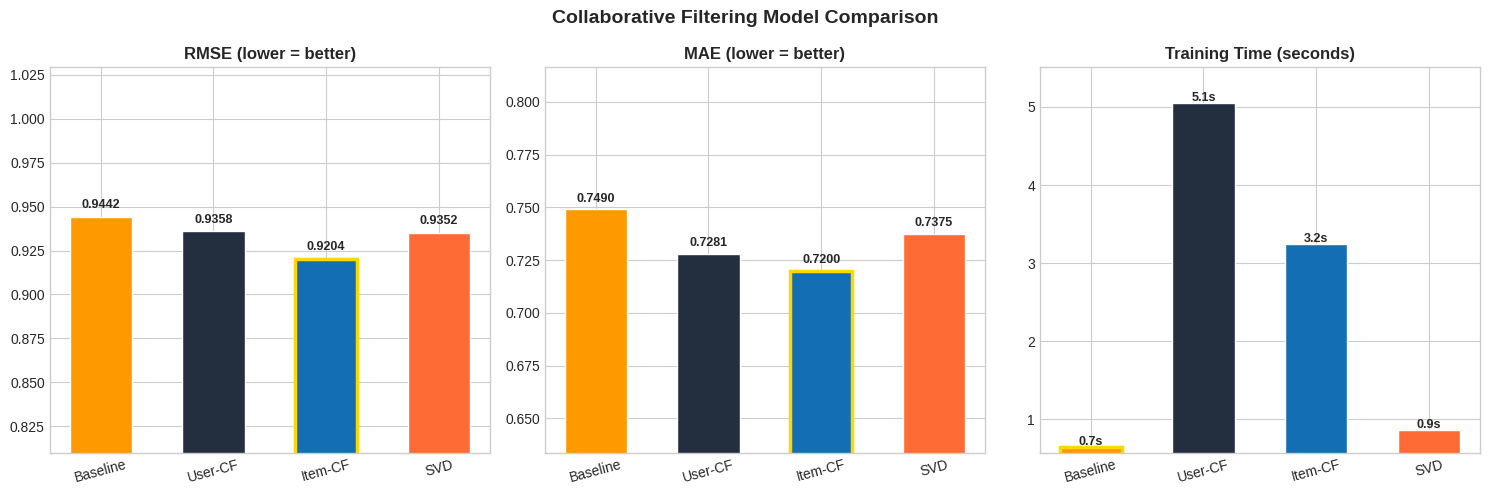

SVD lifts RMSE by 1.0% over Baseline (0.9442 → 0.9352)


In [8]:
# ── Comparison bar chart ──────────────────────────────────────────────────
names = list(results.keys())
rmses = [results[k]['RMSE'] for k in names]
maes  = [results[k]['MAE']  for k in names]
times = [results[k]['time'] for k in names]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Collaborative Filtering Model Comparison', fontsize=14, fontweight='bold')

for ax, vals, metric, fmt in [
    (axes[0], rmses, 'RMSE (lower = better)',        '.4f'),
    (axes[1], maes,  'MAE (lower = better)',         '.4f'),
    (axes[2], times, 'Training Time (seconds)', '.1f'),
]:
    bars = ax.bar(names, vals, color=PALETTE[:len(names)], edgecolor='white', width=0.55)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(min(vals)*0.88, max(vals)*1.09)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        label = f'{val:{fmt}}' + ('s' if 'Time' in metric else '')
        ax.text(bar.get_x() + bar.get_width()/2, val + max(vals)*0.005,
                label, ha='center', fontsize=9, fontweight='bold')
    # Gold border on best (lowest)
    best_idx = vals.index(min(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

baseline_rmse = results['Baseline']['RMSE']
svd_rmse      = results['SVD']['RMSE']
lift          = (baseline_rmse - svd_rmse) / baseline_rmse * 100
print(f"SVD lifts RMSE by {lift:.1f}% over Baseline ({baseline_rmse:.4f} → {svd_rmse:.4f})")

Grid: 8 configs × 3-fold CV = 24 fits

✅ Grid search complete in 23.8s
   Best params  : {'n_factors': 100, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.05}
   Best CV RMSE : 0.9390
   Best CV MAE  : 0.7428

   Final Test RMSE : 0.9296
   Final Test MAE  : 0.7348
   Improvement     : 0.60% RMSE reduction vs default SVD


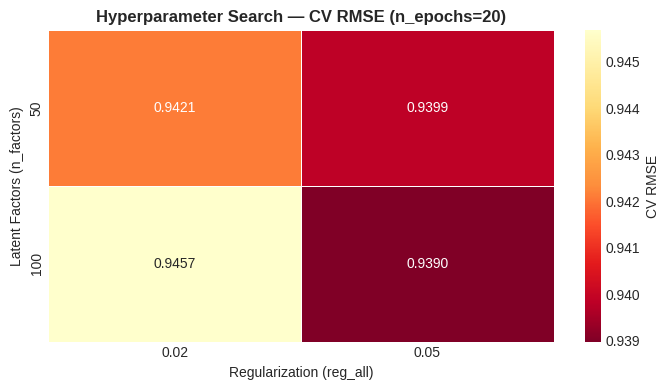

In [9]:
# ── Hyperparameter grid ───────────────────────────────────────────────────
param_grid = {
    'n_factors': [50, 100],
    'n_epochs':  [10, 20],
    'lr_all':    [0.005],
    'reg_all':   [0.02, 0.05],
}

total_configs = 1
for v in param_grid.values():
    total_configs *= len(v)
print(f"Grid: {total_configs} configs × 3-fold CV = {total_configs*3} fits")

t0 = time.time()
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'],
                  cv=3, refit=False, n_jobs=-1)
gs.fit(data)
elapsed = time.time() - t0

best_params = gs.best_params['rmse']
best_cv_rmse = gs.best_score['rmse']

print(f"\n✅ Grid search complete in {elapsed:.1f}s")
print(f"   Best params  : {best_params}")
print(f"   Best CV RMSE : {best_cv_rmse:.4f}")
print(f"   Best CV MAE  : {gs.best_score['mae']:.4f}")

# ── Retrain tuned SVD on full trainset ────────────────────────────────────
best_svd    = SVD(**best_params, random_state=42)
best_svd.fit(trainset)
final_preds = best_svd.test(testset)
final_rmse  = accuracy.rmse(final_preds, verbose=False)
final_mae   = accuracy.mae(final_preds,  verbose=False)

improvement = (results['SVD']['RMSE'] - final_rmse) / results['SVD']['RMSE'] * 100
print(f"\n   Final Test RMSE : {final_rmse:.4f}")
print(f"   Final Test MAE  : {final_mae:.4f}")
print(f"   Improvement     : {improvement:.2f}% RMSE reduction vs default SVD")

# ── Heatmap: n_factors vs reg_all (best n_epochs) ────────────────────────
best_epochs = best_params['n_epochs']
results_cv  = pd.DataFrame(gs.cv_results)

subset = results_cv[results_cv['params'].apply(
    lambda p: p['n_epochs'] == best_epochs and p['lr_all'] == 0.005
)]

pivot_data = {}
for _, row in subset.iterrows():
    p = row['params']
    pivot_data.setdefault(p['n_factors'], {})[p['reg_all']] = row['mean_test_rmse']

pivot_df = pd.DataFrame(pivot_data).T
pivot_df.index.name = 'n_factors'; pivot_df.columns.name = 'reg_all'

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_df, annot=True, fmt='.4f', cmap='YlOrRd_r',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'CV RMSE'})
ax.set_title(f'Hyperparameter Search — CV RMSE (n_epochs={best_epochs})', fontweight='bold')
ax.set_xlabel('Regularization (reg_all)'); ax.set_ylabel('Latent Factors (n_factors)')
plt.tight_layout()
plt.savefig('hyperparam_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
def precision_recall_at_k(predictions, k=10, threshold=4.0):
    """
    Compute Precision@K and Recall@K averaged across all users.

    Args:
        predictions : list of Surprise Prediction namedtuples
        k           : top-K cutoff for the ranked list
        threshold   : minimum true rating to consider an item 'relevant'

    Returns:
        (mean_precision_at_k, mean_recall_at_k)
    """
    # Group by user
    user_preds = defaultdict(list)
    for uid, iid, true_r, est_r, _ in predictions:
        user_preds[uid].append((est_r, true_r))

    precisions, recalls = [], []
    for uid, user_ratings in user_preds.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)  # rank by est
        top_k = user_ratings[:k]
        n_relevant       = sum(1 for _, tr in user_ratings if tr >= threshold)
        n_hits_in_top_k  = sum(1 for _, tr in top_k       if tr >= threshold)
        precisions.append(n_hits_in_top_k / k)
        recalls.append(n_hits_in_top_k / n_relevant if n_relevant > 0 else 0)

    return np.mean(precisions), np.mean(recalls)


# ── Evaluate all models at K = 5, 10, 20 ─────────────────────────────────
k_values       = [5, 10, 20]
ranking_results = {}

print(f"{'Model':<14} {'P@5':>7} {'R@5':>7} {'P@10':>7} {'R@10':>7} {'P@20':>7} {'R@20':>7}")
print("─" * 60)

for name, res in results.items():
    row = {}
    for k in k_values:
        p, r = precision_recall_at_k(res['preds'], k=k, threshold=4.0)
        row[f'P@{k}'] = p
        row[f'R@{k}'] = r
    ranking_results[name] = row
    print(f"{name:<14} {row['P@5']:>7.4f} {row['R@5']:>7.4f} "
          f"{row['P@10']:>7.4f} {row['R@10']:>7.4f} "
          f"{row['P@20']:>7.4f} {row['R@20']:>7.4f}")

# Tuned SVD
tuned_row = {}
for k in k_values:
    p, r = precision_recall_at_k(final_preds, k=k, threshold=4.0)
    tuned_row[f'P@{k}'] = p; tuned_row[f'R@{k}'] = r
ranking_results['SVD (tuned)'] = tuned_row
print(f"{'SVD (tuned)':<14} {tuned_row['P@5']:>7.4f} {tuned_row['R@5']:>7.4f} "
      f"{tuned_row['P@10']:>7.4f} {tuned_row['R@10']:>7.4f} "
      f"{tuned_row['P@20']:>7.4f} {tuned_row['R@20']:>7.4f}")

Model              P@5     R@5    P@10    R@10    P@20    R@20
────────────────────────────────────────────────────────────
Baseline        0.6989  0.5214  0.5790  0.7194  0.4238  0.8681
User-CF         0.7117  0.5263  0.5881  0.7250  0.4302  0.8745
Item-CF         0.7217  0.5327  0.5916  0.7266  0.4309  0.8751
SVD             0.7051  0.5219  0.5837  0.7214  0.4268  0.8711
SVD (tuned)     0.7043  0.5204  0.5862  0.7246  0.4276  0.8715


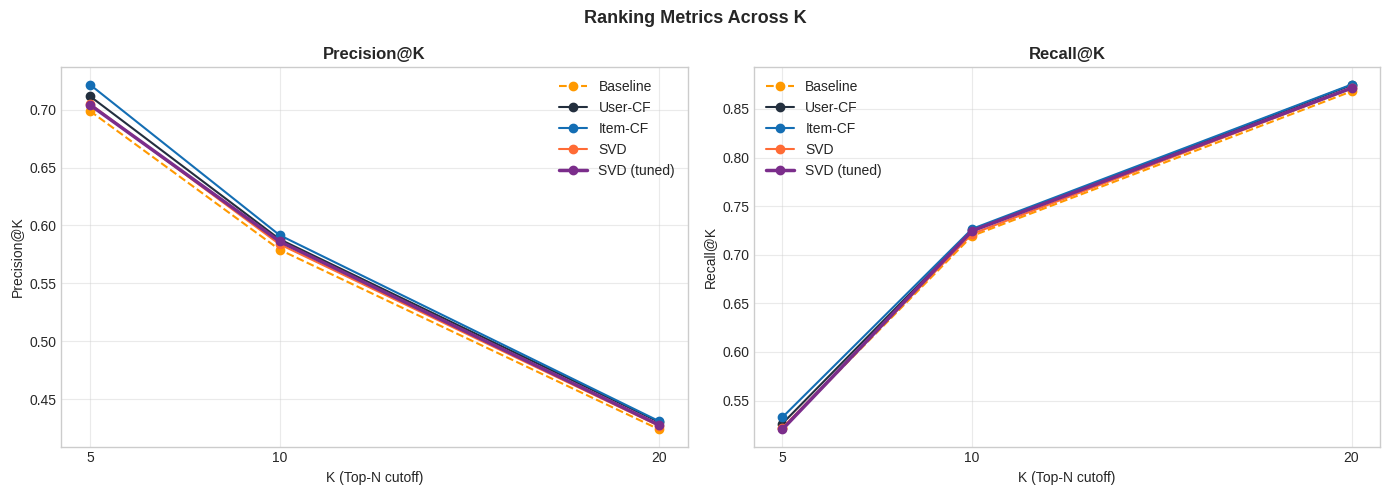


📋 Comprehensive Evaluation Summary


,Model,RMSE,MAE,P@5,R@5,P@10,R@10,P@20,R@20
0,Baseline,0.9442,0.7490,0.6989,0.5214,0.5790,0.7194,0.4238,0.8681
1,User-CF,0.9358,0.7281,0.7117,0.5263,0.5881,0.7250,0.4302,0.8745
2,Item-CF,0.9204,0.7200,0.7217,0.5327,0.5916,0.7266,0.4309,0.8751
3,SVD,0.9352,0.7375,0.7051,0.5219,0.5837,0.7214,0.4268,0.8711
4,SVD (tuned),0.9296,0.7348,0.7043,0.5204,0.5862,0.7246,0.4276,0.8715


In [11]:
# ── Precision & Recall curves across K ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ranking Metrics Across K', fontsize=13, fontweight='bold')

colors = {
    'Baseline': PALETTE[0], 'User-CF':    PALETTE[1],
    'Item-CF':  PALETTE[2], 'SVD':        PALETTE[3],
    'SVD (tuned)': PALETTE[5]
}
all_model_names = list(results.keys()) + ['SVD (tuned)']

for ax, metric_prefix, ylabel in [
    (axes[0], 'P', 'Precision@K'),
    (axes[1], 'R', 'Recall@K'),
]:
    for name in all_model_names:
        vals = [ranking_results[name][f'{metric_prefix}@{k}'] for k in k_values]
        lw   = 2.5 if 'tuned' in name else 1.5
        ls   = '--' if name == 'Baseline' else '-'
        ax.plot(k_values, vals, marker='o', linewidth=lw, linestyle=ls,
                color=colors[name], label=name)
    ax.set_xlabel('K (Top-N cutoff)'); ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight='bold')
    ax.set_xticks(k_values); ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Full summary table ─────────────────────────────────────────────────────
summary_rows = []
for name in all_model_names:
    rmse = results.get(name, {'RMSE': final_rmse})['RMSE']
    mae  = results.get(name, {'MAE':  final_mae})['MAE']
    r    = ranking_results[name]
    summary_rows.append({
        'Model': name, 'RMSE': f"{rmse:.4f}", 'MAE': f"{mae:.4f}",
        'P@5': f"{r['P@5']:.4f}",  'R@5': f"{r['R@5']:.4f}",
        'P@10': f"{r['P@10']:.4f}", 'R@10': f"{r['R@10']:.4f}",
        'P@20': f"{r['P@20']:.4f}", 'R@20': f"{r['R@20']:.4f}",
    })
summary_df = pd.DataFrame(summary_rows)
print("\n📋 Comprehensive Evaluation Summary")
print("=" * 80)
display(summary_df)

In [12]:
def get_top_n_recommendations(model, user_id, ratings_df, movies_df, n=10):
    """
    Generate top-N movie recommendations for a given user.

    Algorithm:
        1. Identify all movies the user has NOT rated
        2. Predict ratings for each candidate movie
        3. Rank by predicted rating descending → return top N

    Args:
        model      : Trained Surprise model (with .predict method)
        user_id    : Integer user ID (1-indexed for ML-100K)
        ratings_df : Full ratings DataFrame
        movies_df  : Movies metadata DataFrame
        n          : Number of recommendations

    Returns:
        DataFrame [Rank | movieId | title | predicted_rating]
    """
    seen    = set(ratings_df[ratings_df['userId'] == user_id]['movieId'])
    unseen  = set(ratings_df['movieId'].unique()) - seen
    preds   = [(mid, model.predict(str(user_id), str(mid)).est) for mid in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)
    top_preds = preds[:n]

    rec_df = pd.DataFrame(top_preds, columns=['movieId', 'predicted_rating'])
    rec_df['movieId'] = rec_df['movieId'].astype(int)
    rec_df = rec_df.merge(movies_df[['movieId', 'title']], on='movieId', how='left')
    rec_df['predicted_rating'] = rec_df['predicted_rating'].round(3)
    rec_df.index = range(1, len(rec_df) + 1)
    rec_df.index.name = 'Rank'
    return rec_df[['movieId', 'title', 'predicted_rating']]


def display_user_profile(user_id, ratings_df, movies_df, top_n=5):
    """Show top-rated movies for context (user history summary)."""
    hist = ratings_df[ratings_df['userId'] == user_id].copy()
    hist = hist.merge(movies_df[['movieId', 'title']], on='movieId', how='left')
    return hist.sort_values('rating', ascending=False)[['title', 'rating']].head(top_n)


# ── Demo: recommendations for 3 sample users ──────────────────────────────
for uid in [1, 50, 200]:
    total_rated = len(ratings_df[ratings_df['userId'] == uid])
    print(f"\n{'='*62}")
    print(f"  User {uid}  ({total_rated} total ratings)")
    print(f"{'='*62}")
    print(f"  ▸ Top 5 previously rated:")
    profile = display_user_profile(uid, ratings_df, movies_df, top_n=5)
    print(profile.to_string(index=False))
    print(f"\n  ▸ Top 10 SVD recommendations:")
    recs = get_top_n_recommendations(best_svd, uid, ratings_df, movies_df, n=10)
    print(recs.to_string())


  User 1  (272 total ratings)
  ▸ Top 5 previously rated:
                          title  rating
                 Sleeper (1973)       5
Empire Strikes Back, The (1980)       5
           Groundhog Day (1993)       5
                  Brazil (1985)       5
            Delicatessen (1991)       5

  ▸ Top 10 SVD recommendations:
      movieId                                                                        title  predicted_rating
Rank                                                                                                        
1         603                                                           Rear Window (1954)             4.679
2         474  Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)             4.638
3         357                                       One Flew Over the Cuckoo's Nest (1975)             4.626
4         513                                                        Third Man, The (1949)             4.580
5         318 

In [13]:
def build_popularity_recommender(ratings_df, movies_df, min_ratings=50):
    """
    Bayesian-smoothed popularity ranking.

    Solves the cold-start problem: when we know nothing about a user,
    recommend the most reliably good movies (not just the most-rated ones).

    Returns:
        DataFrame sorted by bayesian_score (descending)
    """
    movie_stats = ratings_df.groupby('movieId').agg(
        n_ratings=('rating', 'count'),
        mean_rating=('rating', 'mean')
    ).reset_index()

    C   = movie_stats['n_ratings'].mean()   # confidence weight
    mu  = ratings_df['rating'].mean()       # global mean

    movie_stats['bayesian_score'] = (
        (movie_stats['n_ratings'] * movie_stats['mean_rating'] + C * mu) /
        (movie_stats['n_ratings'] + C)
    )

    result = movie_stats[movie_stats['n_ratings'] >= min_ratings]
    result = result.merge(movies_df[['movieId', 'title']], on='movieId', how='left')
    result = result.sort_values('bayesian_score', ascending=False).reset_index(drop=True)
    result.index += 1; result.index.name = 'Rank'
    return result, C, mu


popularity_df, C_weight, global_mean = build_popularity_recommender(
    ratings_df, movies_df, min_ratings=50
)

print(f"Global mean rating   : {global_mean:.3f}")
print(f"Bayesian C weight    : {C_weight:.1f}")
print(f"Movies with ≥50 ratings: {len(popularity_df)}")
print()
print("Top 10 — Bayesian Popularity Ranking:")
display(popularity_df[['title', 'n_ratings', 'mean_rating', 'bayesian_score']].head(10))

# ── Genre-filtered cold-start recs ────────────────────────────────────────
def cold_start_recs(preferred_genres, movies_df, popularity_df, top_n=5):
    """Genre-aware cold-start: new user declares preferences, get tailored recs."""
    available = [g for g in preferred_genres if g in movies_df.columns]
    if not available:
        return popularity_df.head(top_n)
    genre_mask    = movies_df[available].any(axis=1)
    genre_movies  = set(movies_df[genre_mask]['movieId'])
    filtered      = popularity_df[popularity_df['movieId'].isin(genre_movies)]
    return filtered.head(top_n)

print("\n─── Cold-Start Demo: New User Preferences = ['Action', 'Sci-Fi'] ───")
cs_recs = cold_start_recs(['Action', 'Sci-Fi'], movies_df, popularity_df, top_n=5)
display(cs_recs[['title', 'n_ratings', 'bayesian_score']])

Global mean rating   : 3.530
Bayesian C weight    : 59.5
Movies with ≥50 ratings: 603

Top 10 — Bayesian Popularity Ranking:


,title,n_ratings,mean_rating,bayesian_score
Rank,,,,
1,Schindler's List (1993),298,4.466443,4.310667
2,"Shawshank Redemption, The (1994)",283,4.445230,4.286313
3,Star Wars (1977),583,4.358491,4.281809
4,Casablanca (1942),243,4.456790,4.274584
5,"Usual Suspects, The (1995)",267,4.385768,4.229891
6,Rear Window (1954),209,4.387560,4.197609
7,"Silence of the Lambs, The (1991)",390,4.289744,4.189227
8,"Godfather, The (1972)",413,4.283293,4.188482
9,Raiders of the Lost Ark (1981),420,4.252381,4.162787



─── Cold-Start Demo: New User Preferences = ['Action', 'Sci-Fi'] ───


,title,n_ratings,bayesian_score
Rank,,,
3,Star Wars (1977),583,4.281809
8,"Godfather, The (1972)",413,4.188482
9,Raiders of the Lost Ark (1981),420,4.162787
13,Titanic (1997),350,4.141771
16,"Empire Strikes Back, The (1980)",367,4.110326


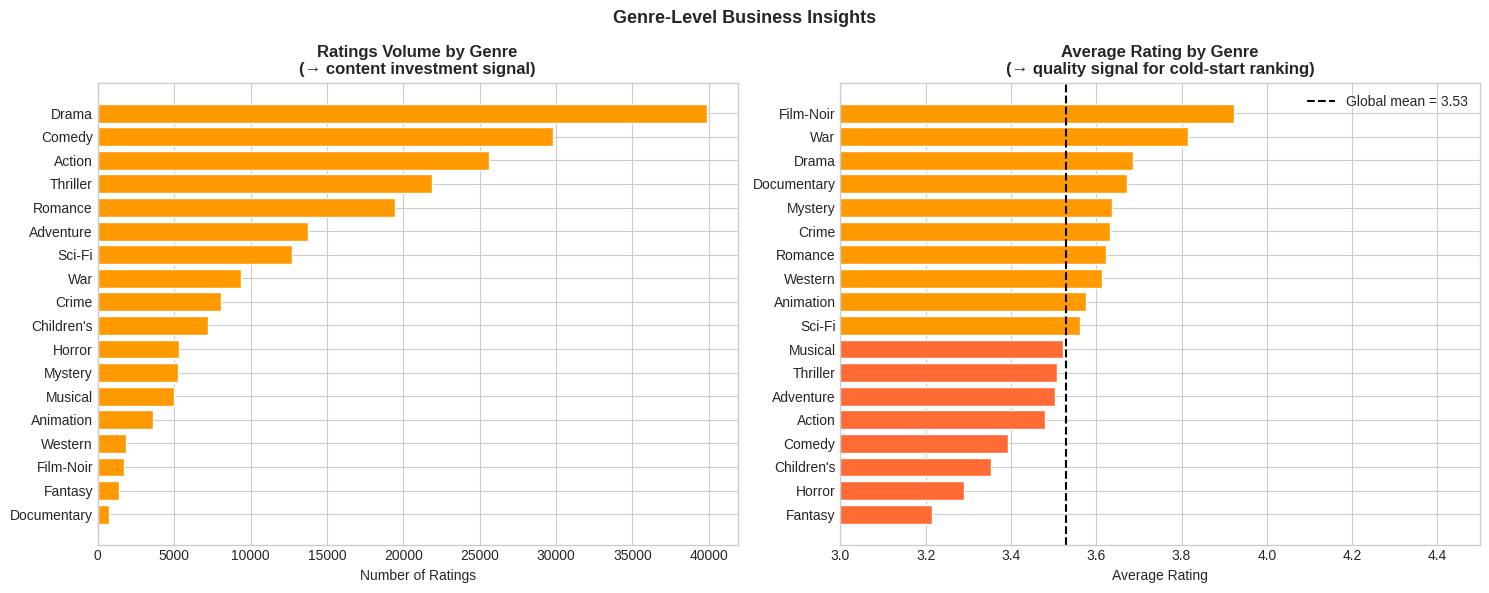


  FINAL EVALUATION SUMMARY — Scalable Hybrid Recommendation System
  Dataset: MovieLens 100K | Framework: scikit-surprise
  Model             RMSE     MAE    P@10    R@10
  ────────────── ─────── ─────── ─────── ───────
  Baseline        0.9442  0.7490  0.5790  0.7194
  User-CF         0.9358  0.7281  0.5881  0.7250
  Item-CF         0.9204  0.7200  0.5916  0.7266
  SVD             0.9352  0.7375  0.5837  0.7214
  SVD (tuned)     0.9296  0.7348  0.5862  0.7246

  Business Insights:
  • Most engaged genre : Drama (39,895 ratings)
  • Highest quality    : Film-Noir (avg 3.92★)
  • Tuning improved RMSE by 0.60% vs default SVD
  • Cold-start users served via popularity fallback: 0 (0.0%)


In [14]:
# ── Genre-level analysis ──────────────────────────────────────────────────
genre_stats = []
for g in GENRE_COLS:
    genre_movies  = movies_df[movies_df[g] == 1]['movieId']
    genre_ratings = ratings_df[ratings_df['movieId'].isin(genre_movies)]
    if len(genre_ratings) > 0:
        genre_stats.append({
            'Genre':       g,
            'Num_Movies':  len(genre_movies),
            'Num_Ratings': len(genre_ratings),
            'Avg_Rating':  round(genre_ratings['rating'].mean(), 3),
        })

genre_df = pd.DataFrame(genre_stats).sort_values('Num_Ratings', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Genre-Level Business Insights', fontsize=13, fontweight='bold')

# Engagement by genre
ax = axes[0]
ax.barh(genre_df['Genre'], genre_df['Num_Ratings'], color=PALETTE[0], edgecolor='white')
ax.set_title('Ratings Volume by Genre\n(→ content investment signal)', fontweight='bold')
ax.set_xlabel('Number of Ratings'); ax.invert_yaxis()

# Quality by genre
ax = axes[1]
gdf_sorted = genre_df.sort_values('Avg_Rating', ascending=False)
clrs = [PALETTE[0] if r >= global_mean else PALETTE[3] for r in gdf_sorted['Avg_Rating']]
ax.barh(gdf_sorted['Genre'], gdf_sorted['Avg_Rating'], color=clrs, edgecolor='white')
ax.axvline(global_mean, color='black', linestyle='--', linewidth=1.5,
           label=f'Global mean = {global_mean:.2f}')
ax.set_title('Average Rating by Genre\n(→ quality signal for cold-start ranking)', fontweight='bold')
ax.set_xlabel('Average Rating'); ax.set_xlim(3.0, 4.5)
ax.invert_yaxis(); ax.legend()

plt.tight_layout()
plt.savefig('genre_insights.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary ──────────────────────────────────────────────────────────
print("\n" + "="*72)
print("  FINAL EVALUATION SUMMARY — Scalable Hybrid Recommendation System")
print("  Dataset: MovieLens 100K | Framework: scikit-surprise")
print("="*72)
print(f"  {'Model':<14} {'RMSE':>7} {'MAE':>7} {'P@10':>7} {'R@10':>7}")
print(f"  {'─'*14} {'─'*7} {'─'*7} {'─'*7} {'─'*7}")
for name in list(results.keys()):
    print(f"  {name:<14} {results[name]['RMSE']:>7.4f} {results[name]['MAE']:>7.4f} "
          f"{ranking_results[name]['P@10']:>7.4f} {ranking_results[name]['R@10']:>7.4f}")
print(f"  {'SVD (tuned)':<14} {final_rmse:>7.4f} {final_mae:>7.4f} "
      f"{tuned_row['P@10']:>7.4f} {tuned_row['R@10']:>7.4f}")

print(f"\n  Business Insights:")
top_genre = genre_df.iloc[0]
top_quality_genre = genre_df.sort_values('Avg_Rating', ascending=False).iloc[0]
lift = (results['SVD']['RMSE'] - final_rmse) / results['SVD']['RMSE'] * 100
print(f"  • Most engaged genre : {top_genre['Genre']} ({top_genre['Num_Ratings']:,} ratings)")
print(f"  • Highest quality    : {top_quality_genre['Genre']} "
      f"(avg {top_quality_genre['Avg_Rating']:.2f}★)")
print(f"  • Tuning improved RMSE by {lift:.2f}% vs default SVD")
print(f"  • Cold-start users served via popularity fallback: "
      f"{(user_activity < 5).sum()} ({(user_activity < 5).sum()/N_USERS:.1%})")

In [15]:
print("✅ Project complete — Scalable Hybrid Recommendation System")
print()
files = ['eda_overview.png', 'cold_start_analysis.png', 'sparsity_pattern.png',
         'model_comparison.png', 'hyperparam_heatmap.png',
         'precision_recall_curve.png', 'genre_insights.png']
print("Generated files:")
for f in files:
    size = os.path.getsize(f) / 1024 if os.path.exists(f) else 0
    status = f"✓  {size:>5.0f} KB" if size > 0 else "✗  not found"
    print(f"  {f:<40} {status}")

print()
print("GitHub-ready structure:")
print("  hybrid-recommender-system/")
print("  ├── ScalableHybridRecommenderSystem.ipynb")
print("  ├── README.md")
print("  ├── requirements.txt")
print("  └── figures/  (7 visualizations)")

✅ Project complete — Scalable Hybrid Recommendation System

Generated files:
  eda_overview.png                         ✓    170 KB
  cold_start_analysis.png                  ✓     79 KB
  sparsity_pattern.png                     ✓     91 KB
  model_comparison.png                     ✓     88 KB
  hyperparam_heatmap.png                   ✓     49 KB
  precision_recall_curve.png               ✓    152 KB
  genre_insights.png                       ✓    123 KB

GitHub-ready structure:
  hybrid-recommender-system/
  ├── ScalableHybridRecommenderSystem.ipynb
  ├── README.md
  ├── requirements.txt
  └── figures/  (7 visualizations)
